Wczytanie datasetu.

In [1]:
import cv2
import os

folder = "/v2_train" # ścieżka do folderu zawierającego dataset - uzupełnić

images = []
filenames = []

for file in os.listdir(folder):
    if file.endswith(".jpg") or file.endswith(".jpeg"):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        images.append(img)
        filenames.append(file)

print(f"Wczytano {len(images)} obrazów")

Wczytano 160 obrazów


Podgląd.

(<matplotlib.image.AxesImage at 0x1f7fe877d10>, Text(0.5, 1.0, 'Obrazek'))

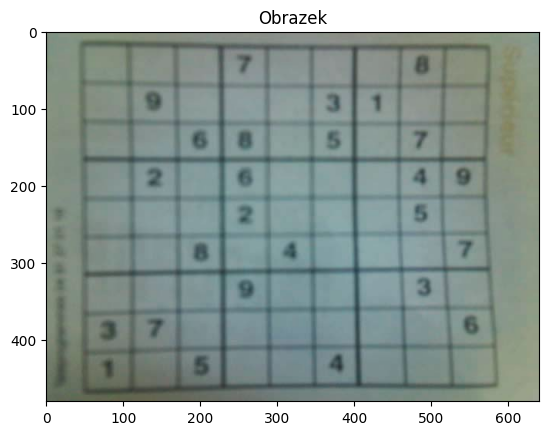

In [4]:
from matplotlib import pyplot as plt

plt.imshow(images[0]), plt.title('Obrazek')

Konwersja do skali szarości i rozmycie Gaussa.

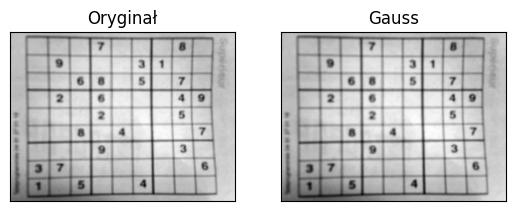

In [15]:
import numpy as np
from matplotlib import pyplot as plt

gray = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0) 

plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Oryginał')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blur, cmap='gray'), plt.title('Gauss')
plt.xticks([]), plt.yticks([])
plt.show()

Binaryzacja adaptacyjna. Konieczna inwersja dla późniejszego przetwarzania.

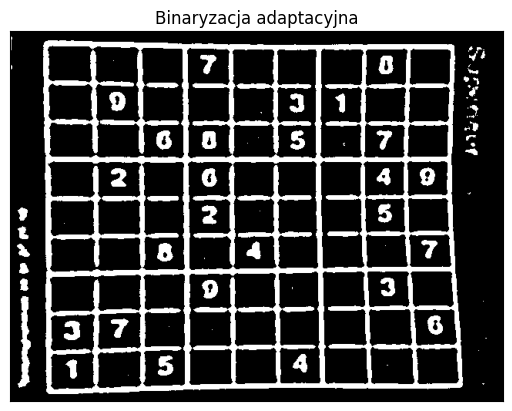

In [17]:
binary = cv2.adaptiveThreshold(
    blur, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    25, 
    3
)

plt.imshow(binary, cmap='gray')
plt.title("Binaryzacja adaptacyjna")
plt.xticks([]), plt.yticks([])
plt.show()

Znalezienie największego konturu.

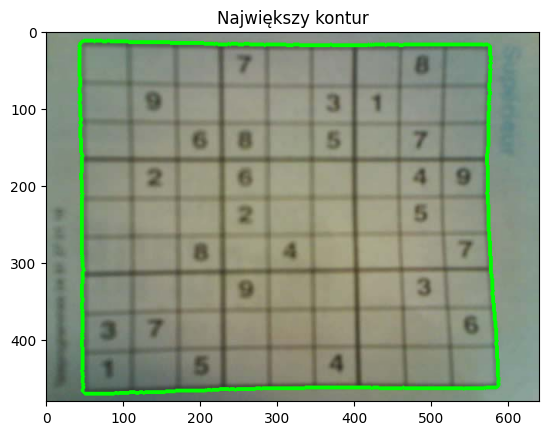

In [18]:
img = images[0].copy()

contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest = max(contours, key=cv2.contourArea)

cv2.drawContours(img, [largest], -1, (0,255,0), 3)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Największy kontur")
plt.show()